# GNSS station catalog EDA (UNR)

This notebook is a quick, lightweight EDA workflow to:
1. Load the **UNR station list** (station_id, lat, lon, elevation).
2. Normalize longitudes to the standard range **[-180, 180]**.
3. Visualize station distribution.
4. Subset stations by a geographic bounding box and export the subset.

Outputs are written to `resources/` so they can be used by the download + NetCDF build steps.


In [2]:
# --- Imports ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.dpi"] = 140


## 1) Point to your UNR station list file

The UNR station list is whitespace-delimited with columns:
`station_id latitude longitude elevation`

Some UNR files use longitudes outside [-180, 180]. We normalize them for plotting and geographic subsetting.

In [3]:
# --- Paths (edit these) ---
UNR_STATIONS_PATH = Path("./resources/all_unr_stations.csv")  # whitespace-delimited: station_id lat lon elev
# Example line:  ALBH 48.389781422 -123.487470112 31.7682625

assert UNR_STATIONS_PATH.exists(), f"Missing: {UNR_STATIONS_PATH.resolve()}"


## 2) Load UNR station catalog

We read the UNR station list into a dataframe `cat` with a consistent schema:
- `id` (optional; set to NA)
- `name` (station code)
- `lat`, `lon` (degrees)
- `elev_m` (meters)
- `depth` (optional; set to NaN)

We also compute `lon_raw` and a normalized `lon` in [-180, 180].

In [4]:
# Load whitespace-delimited station list: station_id, lat, lon, elev_m
raw_cat = pd.read_csv(
    UNR_STATIONS_PATH,
    sep="\\s+",
    header=None,
    names=["name", "lat", "lon_raw", "elev_m"],
)

# Clean types
raw_cat["name"] = raw_cat["name"].astype(str).str.strip()
for c in ["lat", "lon_raw", "elev_m"]:
    raw_cat[c] = pd.to_numeric(raw_cat[c], errors="coerce")

# Normalize longitude to [-180, 180]
raw_cat["lon"] = ((raw_cat["lon_raw"] + 180) % 360) - 180

# Canonical catalog schema (keep depth for downstream, fill as NaN if not present)
cat = raw_cat.copy()
cat = cat[["name", "lat", "lon", "elev_m"]].dropna(subset=["name", "lat", "lon", "elev_m"]).reset_index(drop=True)

display(cat.head())


,name,lat,lon,elev_m
0,00NA,-12.466640,130.843987,104.851046
1,01NA,-12.478224,130.982047,105.408565
2,02NA,-12.355923,130.881729,117.652472
3,0ABI,68.354345,18.816445,431.388473
4,0ABN,65.033682,21.332862,52.762111


### Quick sanity checks

Basic range checks and a quick look at longitude normalization.

In [5]:
print("Catalog rows:", len(cat))
print("Unique stations:", cat["name"].nunique())

assert cat["lat"].between(-90, 90).all(), "Latitude out of range"
assert cat["lon"].between(-180, 180).all(), "Normalized lon out of range"

print("Lon norm range:", float(cat["lon"].min()), "to", float(cat["lon"].max()))


Catalog rows: 23456
Unique stations: 23456
Lon norm range: -179.473949905 to 179.41266843699998


## 3) Plot stations on a simple lat/lon scatter

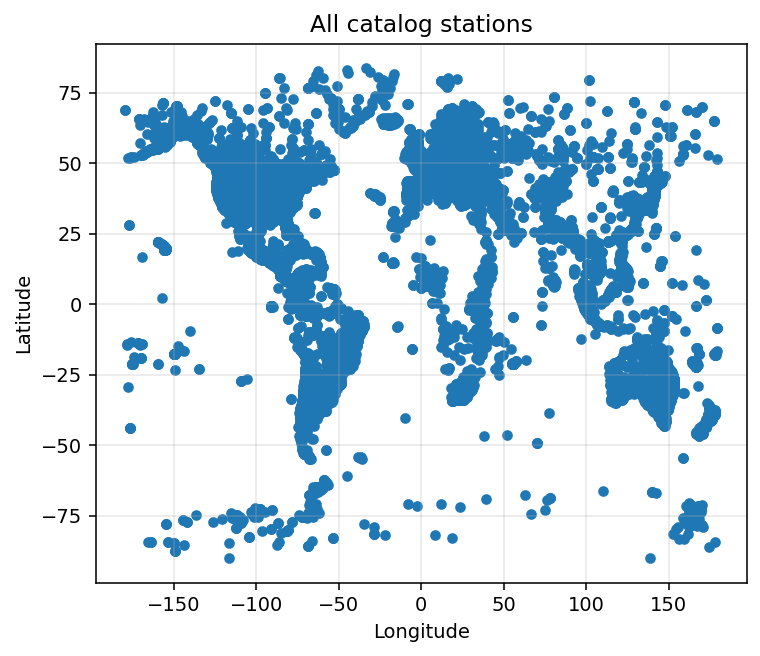

In [6]:
def plot_stations(df: pd.DataFrame, title: str):
    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(df["lon"], df["lat"], s=20)
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)

    # label if few points
    if len(df) <= 30:
        for _, r in df.iterrows():
            ax.annotate(r["name"], (r["lon"], r["lat"]), fontsize=8, xytext=(3, 3), textcoords="offset points")
    plt.show()

plot_stations(cat, "All catalog stations")

## 6) Geographic subset: bounding box

Define a bounding box (min/max lat/lon) and filter either the full catalog or the TXT-matched subset.

Tip: For Pacific Northwest-ish data, a starting guess might be:
- lat: 40–50
- lon: -125–-116

In [7]:
# --- Bounding box  ---
MIN_LAT, MAX_LAT = 39.5, 51.5
MIN_LON, MAX_LON = -130.0, -121.0

def subset_bbox(df: pd.DataFrame, min_lat: float, max_lat: float, min_lon: float, max_lon: float) -> pd.DataFrame:
    m = (
        (df["lat"] >= min_lat) & (df["lat"] <= max_lat) &
        (df["lon"] >= min_lon) & (df["lon"] <= max_lon)
    )
    return df[m].copy().reset_index(drop=True)

cat_bbox = subset_bbox(cat, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)

print("Catalog in bbox:", len(cat_bbox))
cat_bbox.head()


Catalog in bbox: 604


,name,lat,lon,elev_m
0,ABBY,49.072141,-122.197803,195.280394
1,ABOT,49.029436,-122.266570,-4.009165
2,AGNS,42.552765,-124.059114,51.368366
3,AL2H,48.389780,-123.487472,31.750396
4,ALB4,48.389740,-123.487687,30.890637


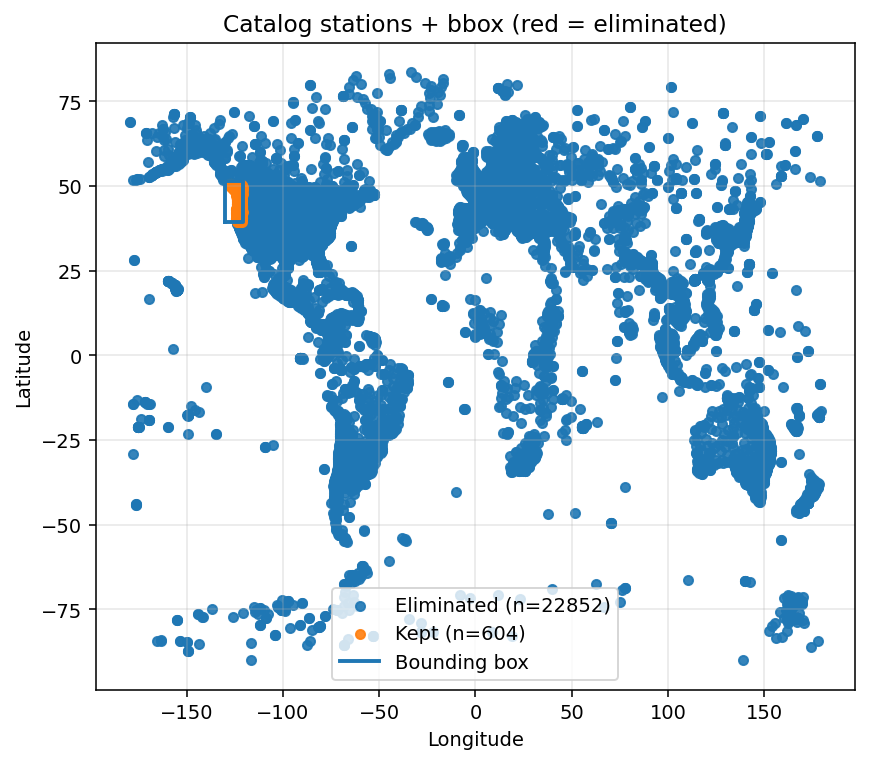

In [8]:
# --- Plot all stations + bbox, eliminated in red ---

def plot_bbox_elimination(df: pd.DataFrame,
                          min_lat: float, max_lat: float,
                          min_lon: float, max_lon: float,
                          title: str = "Catalog stations + bbox (red = eliminated)",
                          label_if_n_leq: int = 30):
    inside = (
        (df["lat"] >= min_lat) & (df["lat"] <= max_lat) &
        (df["lon"] >= min_lon) & (df["lon"] <= max_lon)
    )

    kept = df[inside].copy()
    elim = df[~inside].copy()

    fig, ax = plt.subplots(figsize=(7, 6))

    # plot eliminated first so kept sits "on top"
    ax.scatter(elim["lon"], elim["lat"], s=22, alpha=0.9, label=f"Eliminated (n={len(elim)})")
    ax.scatter(kept["lon"], kept["lat"], s=22, alpha=0.9, label=f"Kept (n={len(kept)})")

    # draw bounding box
    ax.plot(
        [min_lon, max_lon, max_lon, min_lon, min_lon],
        [min_lat, min_lat, max_lat, max_lat, min_lat],
        linewidth=2,
        label="Bounding box"
    )

    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best")

    # optional labels
    if len(df) <= label_if_n_leq:
        for _, r in df.iterrows():
            ax.annotate(r["name"], (r["lon"], r["lat"]),
                        fontsize=8, xytext=(3, 3), textcoords="offset points")

    plt.show()

plot_bbox_elimination(cat, MIN_LAT, MAX_LAT, MIN_LON, MAX_LON)


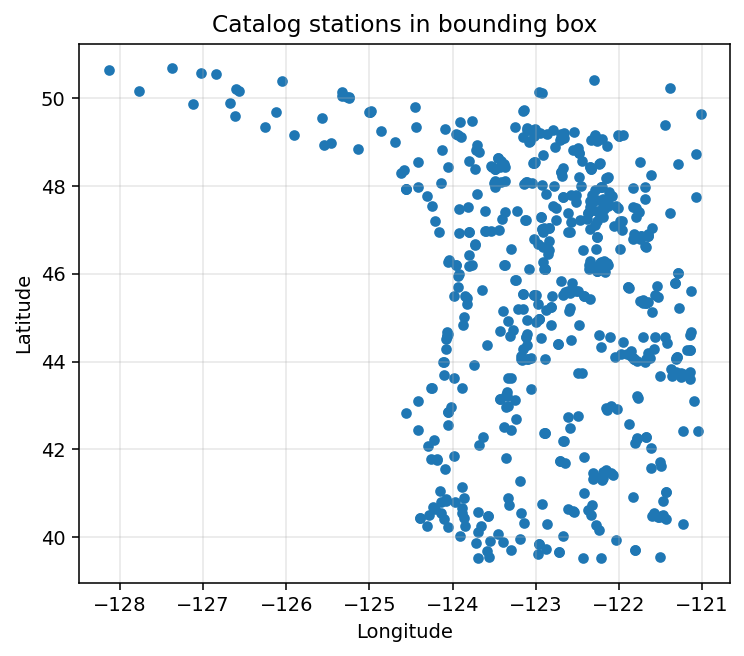

In [9]:
plot_stations(cat_bbox, "Catalog stations in bounding box")


## 4) Export subset

Write the bbox-filtered catalog to `outputs/catalog_subset_bbox.csv` for downstream steps (download + NetCDF build).

In [10]:
OUT_DIR = Path("resources")
OUT_DIR.mkdir(exist_ok=True)

cat_bbox_path = OUT_DIR / "catalog_subset_bbox.csv"
cat_bbox.to_csv(cat_bbox_path, index=False)

print("Wrote:")
print(" -", cat_bbox_path)


Wrote:
 - resources\catalog_subset_bbox.csv
